In [1]:
from datascience import *
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline
plt.style.use('fivethirtyeight')

In [2]:
baby = Table.read_table('../../Data/baby.csv')
baby

Unnamed: 0,Birth.Weight,Gestational.Days,Maternal.Age,Maternal.Height,Maternal.Pregnancy.Weight,Maternal.Smoker
1,120,284,27,62,100,False
2,113,282,33,64,135,False
3,128,279,28,64,115,True
4,108,282,23,67,125,True
5,136,286,25,62,93,False
6,138,244,33,62,178,False
7,132,245,23,65,140,False
8,120,289,25,62,125,False
9,143,299,30,66,136,True
10,140,351,27,68,120,False


In [3]:
baby1 = baby.select(['Gestational.Days','Birth.Weight'])
baby1

Gestational.Days,Birth.Weight
284,120
282,113
279,128
282,108
286,136
244,138
245,132
289,120
299,143
351,140


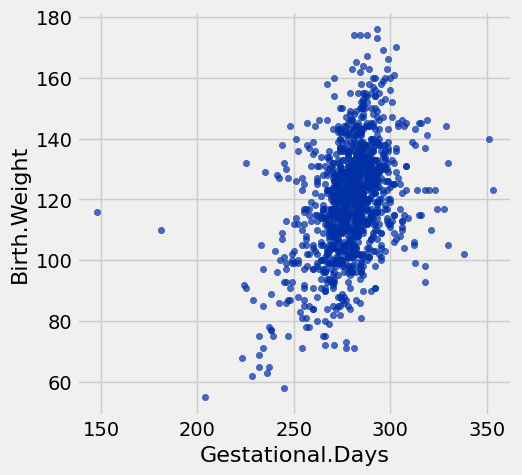

In [4]:
baby1.scatter('Gestational.Days')

In [5]:
def standard_unit(array):
    return (array- np.mean(array))/np.std(array)

In [6]:
def correlation(table,x,y):
    return np.mean(standard_unit(table.column(x)) * standard_unit(table.column(y)))


0.38087142536 0.557550271821


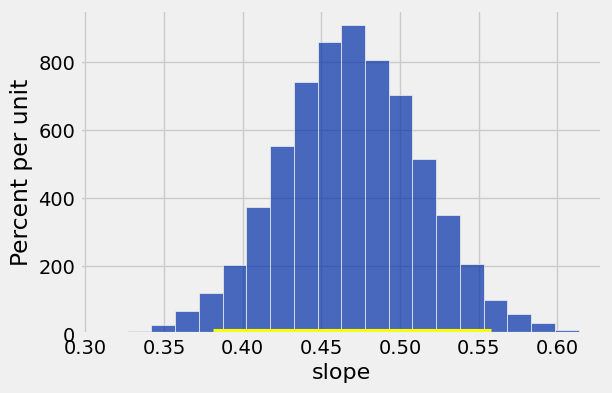

In [7]:
def bootstrap_slope(table,x,y,repitition):
    slope_array = make_array()
    for i in np.arange(repitition):
        sample = table.sample()
        r = correlation(sample,x,y)
        slope = r*np.std(sample.column(1))/np.std(sample.column(0))
        slope_array = np.append(slope_array,slope)
    slope_table = Table().with_column(
        'slope',slope_array
    )    
    slope_table.hist(bins = 20)
    left = percentile(2.5,slope_array)
    right = percentile(97.5,slope_array)
    plt.plot([left,right],[0,0],lw = 8,color = 'yellow')
    print(left, right)
bootstrap_slope(baby1, 'Gestational.Days', 'Birth.Weight', 5000)
    

1.05417202544 1.92270051916


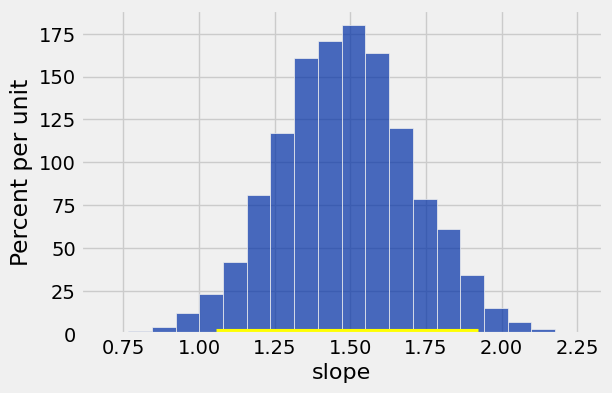

In [8]:
baby2 = baby.select(['Maternal.Height', 'Birth.Weight'])
bootstrap_slope(baby2, 'Maternal.Height', 'Birth.Weight', 5000)

In [9]:
def slope(t,label_1,label_2):
    return correlation(t,label_1,label_2) * np.std(t.column(label_2))/np.std(t.column(label_1))

def intercept(t,label_1,label_2):
    return np.mean(t.column(label_2)) - slope(t,label_1,label_2) * np.mean(t.column(label_1))

In [10]:
def fitted_value(table, x, y, given_x):
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * given_x  + b

In [11]:
fit_300 = fitted_value(baby, 'Gestational.Days', 'Birth.Weight', 300)
fit_300

129.2129241703143

129.21292417


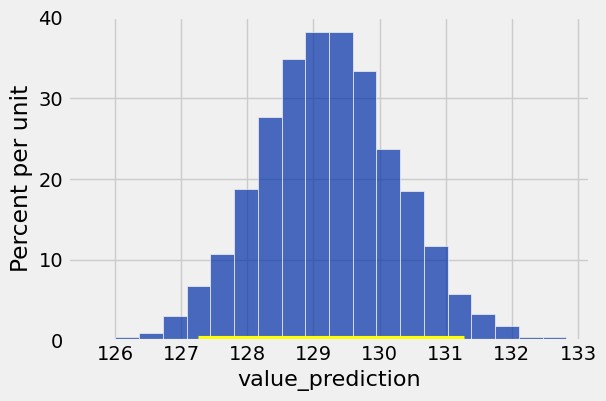

In [12]:
def bootstrap_prediction(table,x,y,given_x,repitition):
    value_array = make_array()
    for i in np.arange(repitition):
        sample1 = table.sample()
        value = fitted_value(sample1,x,y,given_x)
        value_array = np.append(value_array,value)
    result= Table().with_column(
        'value_prediction',value_array
    )
    result.hist(bins = 20)
    left = percentile(2.5,value_array)
    right = percentile(97.5,value_array)
    plt.plot([left,right],[0,0],color = 'yellow',lw = 8)
    original_value = fitted_value(table,x,y,given_x)
    print(original_value)
bootstrap_prediction(baby, 'Gestational.Days', 'Birth.Weight', 300, 5000)